In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import textwrap

%matplotlib inline

In [3]:
idf = pd.read_csv('./reddit-sentiment.csv')  # input df
sdf = pd.read_csv('../yahoo-sp500-historical.csv')  # yahoo S&P500 data

In [4]:
# Convert 'Date' column to datetime format
sdf['Date'] = pd.to_datetime(sdf['Date'])
sdf_2024 = sdf[sdf['Date'].dt.year == 2024]
sdf_2024 = sdf_2024.sort_values(by=['Date'])
sdf_2024 = sdf_2024.reset_index(drop=True)

sdf_2024 = sdf_2024[['Date', 'Close/Last']]
sdf_2024

,Date,Close/Last
0,2024-01-02,4742.83
1,2024-01-03,4704.81
2,2024-01-04,4688.68
3,2024-01-05,4697.24
4,2024-01-08,4763.54
...,...,...
247,2024-12-24,6040.04
248,2024-12-26,6037.59
249,2024-12-27,5970.84
250,2024-12-30,5906.94


In [ ]:
start_price = sdf_2024.iloc[0]['Close/Last']
end_price = sdf_2024.iloc[-1]['Close/Last']
baseline_slope = (start_price - end_price) / len(sdf_2024)

sdf_2024['Baseline'] = start_price - (baseline_slope * sdf_2024.index)
sdf_2024['Deviation'] = sdf_2024['Close/Last'] - sdf_2024['Baseline']

In [16]:
# convert month names to datetime objects
def month_to_datetime(month):
    return datetime.strptime(f"2024-{month}-01", "%Y-%b-%d")

mo_idf = idf.groupby('month', sort=False)['nltk_mu'].mean()
mo_idf_standardized = (mo_idf - mo_idf.mean()) / mo_idf.std()
mo_idf_standardized.index = mo_idf_standardized.index.map(month_to_datetime)

In [12]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

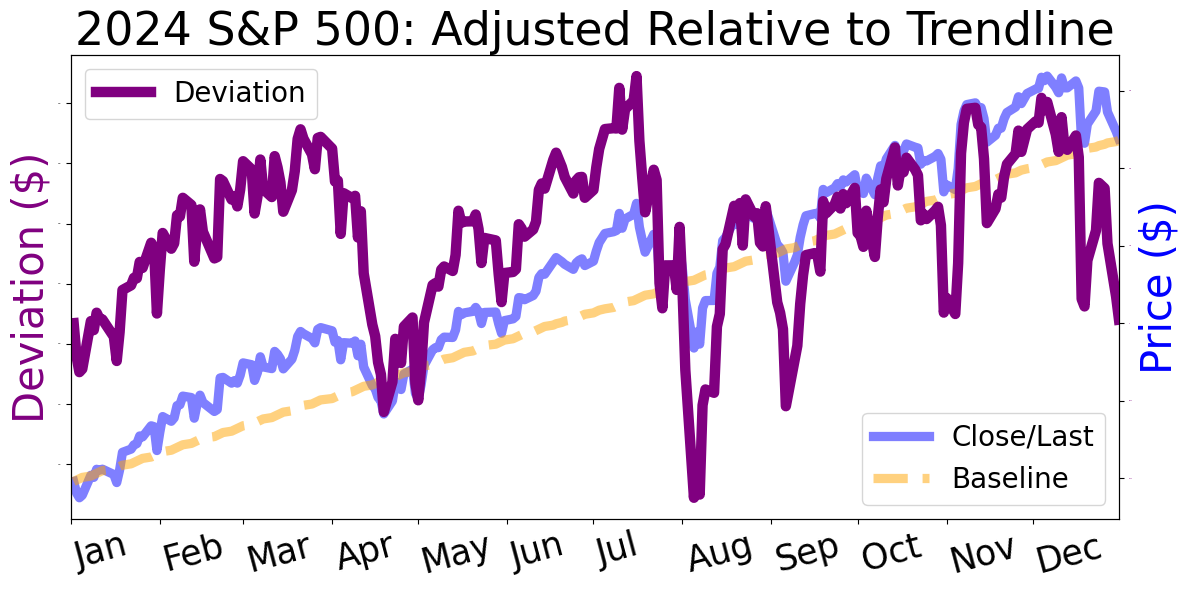

In [75]:
rem = 30
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Close/Last and Baseline on the left y-axis
ax1.plot(sdf_2024['Date'], sdf_2024['Close/Last'], linestyle='-', color='b', label='Close/Last', linewidth=rem/4.5, alpha=0.5)
ax1.plot(sdf_2024['Date'], sdf_2024['Baseline'], linestyle='--', color='orange', label='Baseline', linewidth=rem/4.5, alpha=0.5)
ax1.set_ylabel('Deviation ($)', color='purple', fontsize=rem)
ax1.tick_params(axis='y', labelcolor='black', labelsize=0)  # Disable y-axis ticks
ax1.legend(loc='lower right', fontsize=rem/1.5)
ax1.grid(False)
ax1.set_xticks(mo_idf_standardized.index)
ax1.set_xticklabels(months, rotation=15, ha='left', size=rem/1.2)
ax1.tick_params(axis='x')
ax1.set_xlim(sdf_2024['Date'].iloc[0] - timedelta(days=1), sdf_2024['Date'].iloc[-1])

# Create a second y-axis for Deviation
ax2 = ax1.twinx()
ax2.plot(sdf_2024['Date'], sdf_2024['Deviation'], linestyle='-', color='purple', label='Deviation', linewidth=rem/4)
ax2.set_ylabel('Price ($)', color='blue', fontsize=rem)
ax2.tick_params(axis='y', labelcolor='purple', labelsize=0)
ax2.legend(loc='upper left', fontsize=rem/1.5)
ax2.grid(False)

plt.tight_layout()
# mag = sdf_2024['Deviation'].max()
# mag += mag / 12

# colors = ['green' if val > 0 else 'red' for val in mo_idf_standardized]
# widths = [delta.days for delta in (mo_idf_standardized.index[1:] - mo_idf_standardized.index[:-1])] + [31]
# plt.bar(mo_idf_standardized.index, mo_idf_standardized * (mag / 3), color=colors, width=widths, align='edge')

plt.title('2024 S&P 500: Adjusted Relative to Trendline', fontsize=rem*1.1)
# plt.xlabel('Date')
# plt.ylabel('Price Deviation from Trendline ($)')
# plt.grid(True)
# plt.xticks(rotation=45, ticks=mo_idf_standardized.index, labels=months)

# plt.ylim(-mag, mag)

# plt.xlim(sdf_2024['Date'].iloc[0], sdf_2024['Date'].iloc[-1])
plt.tight_layout()
plt.show()